In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/brain-cancer-mri-dataset/dataset.csv
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer/brain_tumor/brain_tumor_1402.jpg
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer/brain_tumor/brain_tumor_0483.jpg
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer/brain_tumor/brain_tumor_0141.jpg
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer/brain_tumor/brain_tumor_1531.jpg
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer/brain_tumor/brain_tumor_0285.jpg
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer/brain_tumor/brain_tumor_0062.jpg
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer/brain_tumor/brain_tumor_1891.jpg
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer/brain_tumor/brain_tumor_1322.jpg
/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI d

2026-01-06 17:52:47.359634: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767721967.510425      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767721967.551181      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767721967.877545      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767721967.877588      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767721967.877591      24 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0

Original distribution:
 label
normal          14715
brain_tumor      2048
brain_glioma     2004
brain_menin      2004
Name: count, dtype: int64

Balanced distribution:
 label
normal          2505
brain_menin     2004
brain_glioma    2004
brain_tumor     2004
Name: count, dtype: int64
Found 6813 validated image filenames belonging to 4 classes.
Found 852 validated image filenames belonging to 4 classes.
Found 852 validated image filenames belonging to 4 classes.

Classes: ['brain_glioma', 'brain_menin', 'brain_tumor', 'normal']


I0000 00:00:1767721985.428928      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

...

213/213 ━━━━━━━━━━━━━━━━━━━━ 76s 357ms/step - accuracy: 0.9318 - loss: 0.1843 - val_accuracy: 0.9601 - val_loss: 0.0966 - learning_rate: 1.0000e-04
Epoch 15/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 74s 349ms/step - accuracy: 0.9418 - loss: 0.1617 - val_accuracy: 0.9542 - val_loss: 0.1052 - learning_rate: 1.0000e-04
Epoch 16/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 75s 351ms/step - accuracy: 0.9469 - loss: 0.1694 - val_accuracy: 0.9601 - val_loss: 0.0954 - learning_rate: 1.0000e-04
Epoch 17/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.9430 - loss: 0.1655

213/213 ━━━━━━━━━━━━━━━━━━━━ 77s 361ms/step - accuracy: 0.9430 - loss: 0.1655 - val_accuracy: 0.9636 - val_loss: 0.0872 - learning_rate: 1.0000e-04
Epoch 18/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.9427 - loss: 0.1634

213/213 ━━━━━━━━━━━━━━━━━━━━ 75s 350ms/step - accuracy: 0.9428 - loss: 0.1633 - val_accuracy: 0.9648 - val_loss: 0.0898 - learning_rate: 1.0000e-04
Epoch 19/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.9468 - loss: 0.1509

213/213 ━━━━━━━━━━━━━━━━━━━━ 75s 353ms/step - accuracy: 0.9468 - loss: 0.1509 - val_accuracy: 0.9683 - val_loss: 0.0777 - learning_rate: 1.0000e-04
Epoch 20/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 75s 354ms/step - accuracy: 0.9500 - loss: 0.1422 - val_accuracy: 0.9613 - val_loss: 0.0854 - learning_rate: 1.0000e-04
Epoch 21/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 75s 350ms/step - accuracy: 0.9506 - loss: 0.1356 - val_accuracy: 0.9601 - val_loss: 0.0913 - learning_rate: 1.0000e-04
Epoch 22/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 75s 351ms/step - accuracy: 0.9483 - loss: 0.1453 - val_accuracy: 0.9671 - val_loss: 0.0812 - learning_rate: 1.0000e-04
Epoch 23/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.9506 - loss: 0.1375

213/213 ━━━━━━━━━━━━━━━━━━━━ 75s 353ms/step - accuracy: 0.9506 - loss: 0.1375 - val_accuracy: 0.9695 - val_loss: 0.0759 - learning_rate: 1.0000e-04
Epoch 24/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 76s 355ms/step - accuracy: 0.9543 - loss: 0.1278 - val_accuracy: 0.9695 - val_loss: 0.0728 - learning_rate: 1.0000e-04
Epoch 25/25
213/213 ━━━━━━━━━━━━━━━━━━━━ 75s 351ms/step - accuracy: 0.9524 - loss: 0.1277 - val_accuracy: 0.9636 - val_loss: 0.0812 - learning_rate: 1.0000e-04


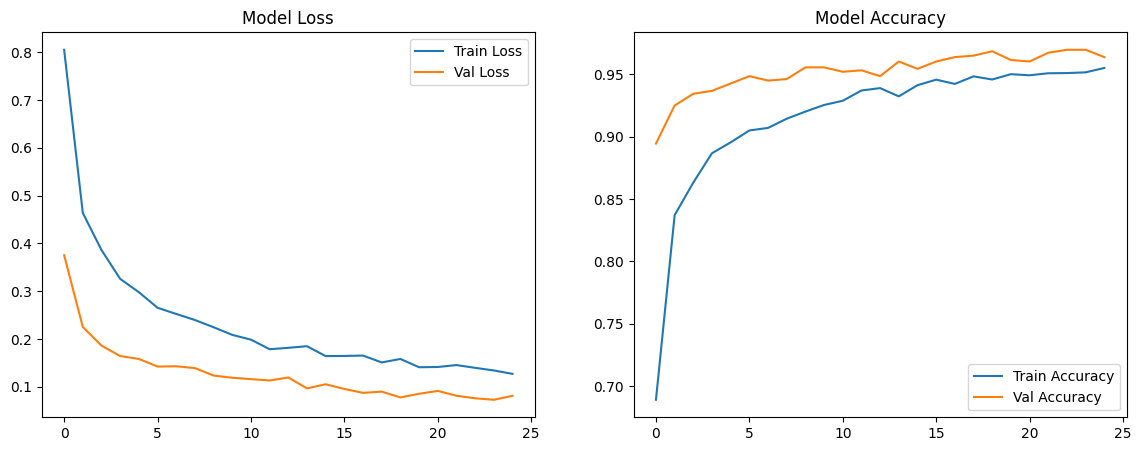

27/27 ━━━━━━━━━━━━━━━━━━━━ 20s 533ms/step


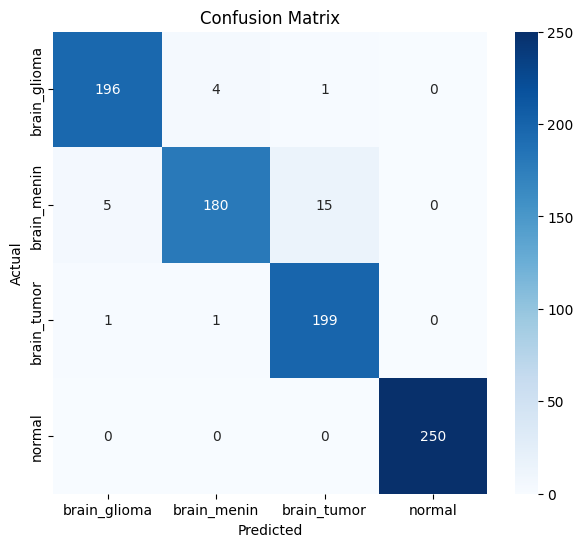


📋 Classification Report:

              precision    recall  f1-score   support

brain_glioma       0.97      0.98      0.97       201
 brain_menin       0.97      0.90      0.94       200
 brain_tumor       0.93      0.99      0.96       201
      normal       1.00      1.00      1.00       250

    accuracy                           0.97       852
   macro avg       0.97      0.97      0.97       852
weighted avg       0.97      0.97      0.97       852


📊 Detailed Metrics per Class:

              precision    recall  f1-score  support
brain_glioma   0.970297  0.975124  0.972705    201.0
brain_menin    0.972973  0.900000  0.935065    200.0
brain_tumor    0.925581  0.990050  0.956731    201.0
normal         1.000000  1.000000  1.000000    250.0

📈 Average Metrics:
precision    0.969092
recall       0.968310
f1-score     0.968110
Name: weighted avg, dtype: float64


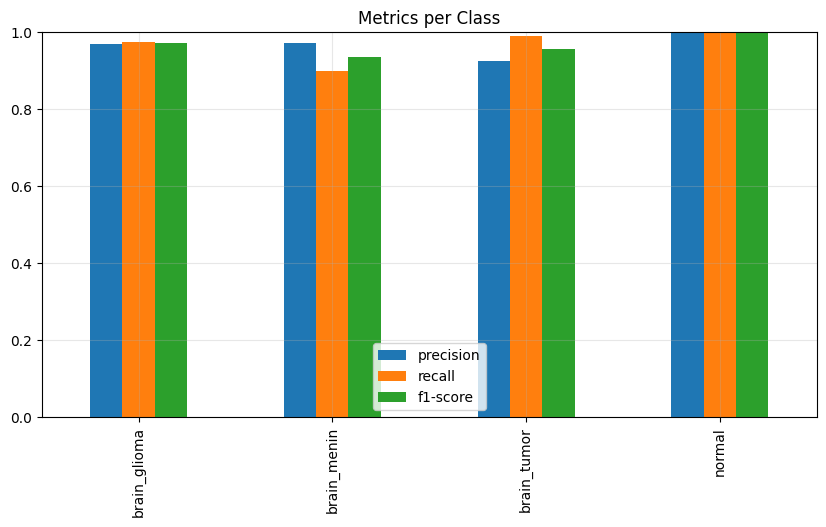


FINAL TRAINING SUMMARY
Model: EfficientNetB0
Classes: ['brain_glioma', 'brain_menin', 'brain_tumor', 'normal']
Train samples: 6813
Validation samples: 852
Test samples: 852
Best Validation Accuracy: 0.9694835543632507
Final Test Accuracy: 0.9683098591549296

✅ Model saved as brain_mri_effnet_final.h5


In [ ]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow:", tf.__version__)
images, labels = [], []

tumor_path = "/kaggle/input/brain-cancer-mri-dataset/Brain_Cancer raw MRI data/Brain_Cancer"
normal_path = "/kaggle/input/brain-mri-images/GAN-Traning Images"

for cls in os.listdir(tumor_path):
    for img in os.listdir(os.path.join(tumor_path, cls)):
        images.append(os.path.join(tumor_path, cls, img))
        labels.append(cls)

for img in os.listdir(normal_path):
    images.append(os.path.join(normal_path, img))
    labels.append("normal")

df = pd.DataFrame({"image": images, "label": labels})
print("\nOriginal distribution:\n", df["label"].value_counts())
min_count = df["label"].value_counts().min()
balanced = []

for cls in df["label"].unique():
    subset = df[df["label"] == cls]
    n = min_count if cls != "normal" else int(min_count * 1.25)
    balanced.append(subset.sample(n=n, random_state=42))

df = pd.concat(balanced).sample(frac=1, random_state=42).reset_index(drop=True)

print("\nBalanced distribution:\n", df["label"].value_counts())

train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=42
)

val_df, test_df = train_test_split(
    test_df, test_size=0.5, stratify=test_df["label"], random_state=42
)

IMG_SIZE = (224, 224)
BATCH = 32

train_gen = ImageDataGenerator(
    preprocessing_function=keras.applications.efficientnet.preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(
    preprocessing_function=keras.applications.efficientnet.preprocess_input
)

train_ds = train_gen.flow_from_dataframe(
    train_df,
    x_col="image",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=True
)

val_ds = test_gen.flow_from_dataframe(
    val_df,
    x_col="image",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=True
)

test_ds = test_gen.flow_from_dataframe(
    test_df,
    x_col="image",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    shuffle=False
)

NUM_CLASSES = len(train_ds.class_indices)
CLASS_NAMES = list(train_ds.class_indices.keys())

print("\nClasses:", CLASS_NAMES)

class_weights = compute_class_weight(
    "balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)
class_weight_dict = dict(enumerate(class_weights))
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()
callbacks = [
    ModelCheckpoint("best_effnet.h5", monitor="val_accuracy", save_best_only=True),
    EarlyStopping(patience=10, restore_best_weights=True),
    ReduceLROnPlateau(patience=5, factor=0.3)
]
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Model Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Model Accuracy")
plt.legend()

plt.show()
pred = model.predict(test_ds)
y_pred = np.argmax(pred, axis=1)
y_true = test_ds.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
df_metrics = pd.DataFrame(report).transpose()

print("\n📋 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

print("\n📊 Detailed Metrics per Class:\n")
print(df_metrics.iloc[:-3][["precision","recall","f1-score","support"]])

print("\n📈 Average Metrics:")
print(df_metrics.loc["weighted avg"][["precision","recall","f1-score"]])
df_metrics.iloc[:-3][["precision","recall","f1-score"]].plot(
    kind="bar",
    figsize=(10,5),
    ylim=(0,1),
    title="Metrics per Class"
)
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "="*60)
print("FINAL TRAINING SUMMARY")
print("="*60)
print("Model: EfficientNetB0")
print("Classes:", CLASS_NAMES)
print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))
print("Best Validation Accuracy:", max(history.history["val_accuracy"]))
print("Final Test Accuracy:", df_metrics.loc["accuracy", "precision"])
print("="*60)
model.save("brain_mri_effnet_final.h5")
print("\n✅ Model saved as brain_mri_effnet_final.h5")
